# Lesson 20 — The bootstrap & permutation tests

*Part 2 · Lesson 20 of 20  ·  data: Old Faithful · ToothGrowth*

**←** [Lesson 19: Multiple regression (intro)](19-multiple-regression.ipynb)  ·  [↑ Course map](../rendered/index.html)

**Same idea, another way:**  [Another dataset →](20-bootstrap-permutation~another-dataset.ipynb)  ·  [The code behind it →](20-bootstrap-permutation~the-code.ipynb)

Every test so far has leaned on a **formula**: a standard error, a $t^{*}$ multiplier, a known
distribution under the null. But those formulas come with fine print — "the data is roughly normal,"
"the statistic is a mean," "the sample is big enough." What do you do when the statistic is a
**median** (no clean formula at all), or your sample is tiny and lopsided?

You **resample**. This is the capstone idea of the whole course: instead of *trusting* a formula,
**make the computer do the experiment over and over and watch what happens.** Two resampling moves
cover an astonishing amount of ground — the **bootstrap** (for confidence intervals on *any*
statistic) and the **permutation test** (for "is the difference between two groups real?"). Run each
grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

FAITHFUL_URL = 'https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv'
TOOTH_URL = 'https://vincentarelbundock.github.io/Rdatasets/csv/datasets/ToothGrowth.csv'

faithful = sl.load_csv('faithful.csv', url=FAITHFUL_URL)
tooth = sl.load_csv('ToothGrowth.csv', url=TOOTH_URL)

eruptions = faithful['eruptions'].to_numpy()    # eruption durations (minutes), n = 272
print(f'Old Faithful: {len(eruptions)} eruption durations (minutes)')
print(f'ToothGrowth:  {len(tooth)} guinea pigs, supplement = {sorted(tooth["supp"].unique())}')
faithful.head()

Old Faithful: 272 eruption durations (minutes)
ToothGrowth:  60 guinea pigs, supplement = ['OJ', 'VC']


,rownames,eruptions,waiting
0,1,3.600,79
1,2,1.800,54
2,3,3.333,74
3,4,2.283,62
4,5,4.533,85


## 1) The problem: a statistic with no formula

The textbook confidence interval for a **mean** is $\bar{x} \pm t^{*}\, s/\sqrt{n}$ — see the
confidence-interval flagship. That recipe exists because the **standard error of the mean** has a
tidy formula, $s/\sqrt{n}$, handed to us by the Central Limit Theorem.

Now look at Old Faithful's eruption durations. They are famously **bimodal** — two clumps, short
eruptions near 2 minutes and long ones near 4.5 — so the *mean* sits in the empty valley between the
peaks where almost no eruption actually lands. The **median** is the more honest "typical" value
here. But quick: what is the standard error of a *median*? There is **no clean formula** for it. The
flagship recipe simply doesn't apply.

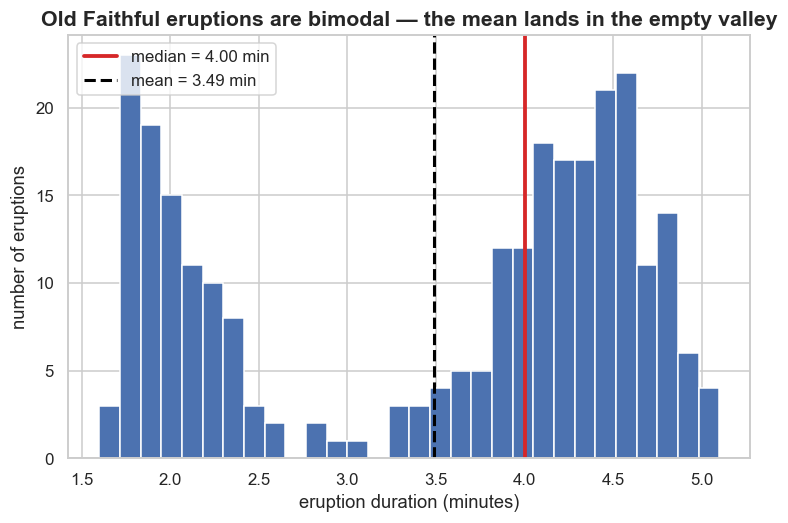

Notice: the mean falls between the two peaks, where eruptions almost never happen.
The MEDIAN is the better "typical" value here — but it has no standard-error formula.


In [2]:
fig, ax = plt.subplots()
ax.hist(eruptions, bins=30, color='#4c72b0', edgecolor='white')
ax.axvline(np.median(eruptions), color='#d62728', lw=2.5, label=f'median = {np.median(eruptions):.2f} min')
ax.axvline(eruptions.mean(), color='black', lw=2, ls='--', label=f'mean = {eruptions.mean():.2f} min')
ax.set_xlabel('eruption duration (minutes)'); ax.set_ylabel('number of eruptions')
ax.set_title('Old Faithful eruptions are bimodal — the mean lands in the empty valley')
ax.legend(); plt.show()
print('Notice: the mean falls between the two peaks, where eruptions almost never happen.')
print('The MEDIAN is the better "typical" value here — but it has no standard-error formula.')

## 2) The bootstrap idea — pull yourself up by your own bootstraps

Here is the trick, and it sounds like cheating the first time you hear it.

A confidence interval is really a question about the **sampling distribution**: *if I could draw many
fresh samples from the population, how much would my statistic bounce around?* We can't draw fresh
samples — we only have the **one** sample we collected. **But our sample is our best picture of the
population.** So we treat it *as* the population and draw new samples **from it**:

> **Resample your data WITH replacement**, the same size as the original. Recompute the statistic.
> Repeat thousands of times. The spread of those recomputed values estimates the sampling
> distribution — for *any* statistic you like.

"With replacement" is the whole engine. Each bootstrap sample picks $n$ values from your $n$ data
points, allowing repeats — so some original points appear twice or three times, others not at all.
That reshuffling is exactly the sample-to-sample wobble the standard error was trying to capture, and
we get it **without any formula**.

In [3]:
# A single bootstrap resample of the eruptions, to see the mechanism.
rng = np.random.default_rng(42)        # change this seed to draw a different bootstrap world
n = len(eruptions)

one_resample = rng.choice(eruptions, size=n, replace=True)   # same size n, WITH replacement
print(f'Original sample: n = {n}, median = {np.median(eruptions):.3f} min')
print(f'One resample:    n = {len(one_resample)}, median = {np.median(one_resample):.3f} min')

# Some points get picked multiple times; others not at all. Count how many ORIGINAL POSITIONS
# (indices) never got drawn -- this is the quantity the 1/e fact is about.
idx = rng.choice(np.arange(n), size=n, replace=True)   # which original positions this resample drew
left_out = n - len(np.unique(idx))                     # positions never selected
print(f'\nThis resample left out {left_out} of the {n} original points '
      f'({left_out / n:.0%} -- never drawn even once)')
print('(on average a bootstrap sample leaves out about 1/e = 37% of the original points).')

Original sample: n = 272, median = 4.000 min
One resample:    n = 272, median = 3.850 min

This resample left out 101 of the 272 original points (37% -- never drawn even once)
(on average a bootstrap sample leaves out about 1/e = 37% of the original points).


## 3) A bootstrap confidence interval for the median

Now we do that thousands of times and collect the medians. The result — the **bootstrap
distribution** — is our stand-in for the sampling distribution of the median. To get a 95% confidence
interval we use the **percentile method**: just take the **2.5th and 97.5th percentiles** of the
bootstrap medians. The middle 95% of "where the median landed under resampling" *is* the interval.

In [4]:
def bootstrap_statistic(data, stat_fn, n_boot=10000, seed=42):
    '''Resample `data` WITH replacement n_boot times; return stat_fn of each resample.'''
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    n = len(data)
    out = np.empty(n_boot)
    for i in range(n_boot):
        resample = rng.choice(data, size=n, replace=True)
        out[i] = stat_fn(resample)
    return out

boot_medians = bootstrap_statistic(eruptions, np.median, n_boot=10000)

lo, hi = np.percentile(boot_medians, [2.5, 97.5])     # the percentile method
print(f'Sample median            = {np.median(eruptions):.3f} min')
print(f'95% bootstrap CI (median)= ({lo:.3f}, {hi:.3f}) min')
print(f'Bootstrap SE of median   = {boot_medians.std(ddof=1):.4f} min   <- a number with no textbook formula!')

Sample median            = 4.000 min
95% bootstrap CI (median)= (3.833, 4.117) min
Bootstrap SE of median   = 0.0801 min   <- a number with no textbook formula!


We just produced a confidence interval and a standard error for the **median** — a statistic the
classical toolkit gives us no formula for at all. Let's picture the bootstrap distribution with the
interval marked.

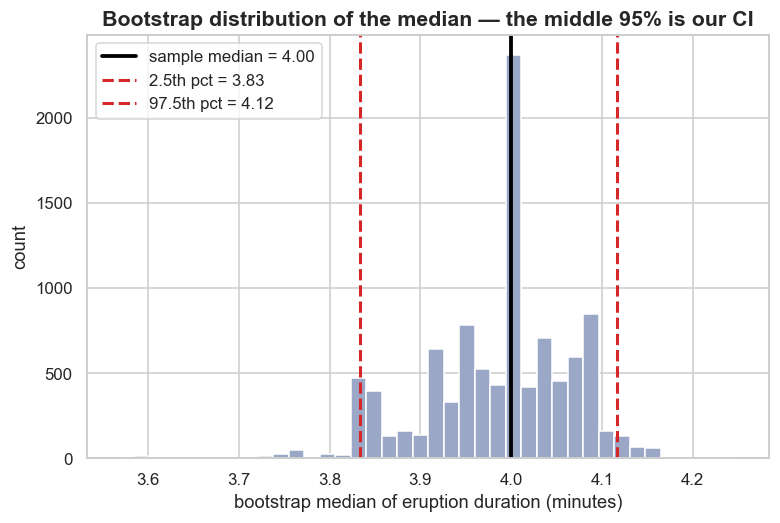

See the "lumpy" spikes? The median of these data can only land on a few values,
so its bootstrap distribution is discrete - exactly the kind of mess a smooth formula
would have hidden. The bootstrap shows the honest, jagged truth.


In [5]:
fig, ax = plt.subplots()
ax.hist(boot_medians, bins=40, color='#9aa7c7', edgecolor='white')
ax.axvline(np.median(eruptions), color='black', lw=2.5, label=f'sample median = {np.median(eruptions):.2f}')
ax.axvline(lo, color='#d62728', lw=2, ls='--', label=f'2.5th pct = {lo:.2f}')
ax.axvline(hi, color='#d62728', lw=2, ls='--', label=f'97.5th pct = {hi:.2f}')
ax.set_xlabel('bootstrap median of eruption duration (minutes)'); ax.set_ylabel('count')
ax.set_title('Bootstrap distribution of the median — the middle 95% is our CI')
ax.legend(); plt.show()
print('See the "lumpy" spikes? The median of these data can only land on a few values,')
print('so its bootstrap distribution is discrete - exactly the kind of mess a smooth formula')
print('would have hidden. The bootstrap shows the honest, jagged truth.')

**Reading the interval (the three levels):**

- **The math:** resample with replacement $B$ times, compute the median each time, and slice off the
  2.5th and 97.5th percentiles of those $B$ medians.
- **The meaning:** the bootstrap distribution *imitates* the sampling distribution, so its middle 95%
  is a range of plausible values for the true median — built entirely by simulation, no formula.
- **The interpretation:** a typical Old Faithful eruption lasts about **4 minutes**, and we're 95%
  confident the true median sits roughly between the dashed lines. (Same long-run-coverage meaning as
  any confidence interval — review the flagship if "95% confident" still feels slippery.)

> **Honesty about the bootstrap:** it is not magic. It can only know what your sample knows — if your
> sample is tiny or unrepresentative, the bootstrap faithfully reproduces *that* limitation. And the
> simple percentile method can be slightly off for very skewed statistics or very small $n$. It is a
> superb general-purpose tool, not a license to ignore a bad sample.

## 4) Validate the method: bootstrap vs. the textbook formula

A new method is only trustworthy if it **agrees with the old one where the old one works.** The
classical t-interval *does* apply to the **mean**. So let's bootstrap the **mean** of the same
eruptions and check that the bootstrap CI lands on top of the textbook t-interval. If a brand-new
simulation reproduces a century-old formula, we can trust it on the median where no formula exists.

In [6]:
# (a) Bootstrap CI for the MEAN
boot_means = bootstrap_statistic(eruptions, np.mean, n_boot=10000)
b_lo, b_hi = np.percentile(boot_means, [2.5, 97.5])

# (b) Classical t-interval for the MEAN (the flagship recipe)
xbar = eruptions.mean()
s = eruptions.std(ddof=1)
se = s / np.sqrt(n)
tcrit = stats.t.ppf(0.975, df=n - 1)
t_lo, t_hi = xbar - tcrit * se, xbar + tcrit * se

print(f'Sample mean = {xbar:.4f} min\n')
print(f'Bootstrap 95% CI (mean): ({b_lo:.4f}, {b_hi:.4f})')
print(f't-interval  95% CI (mean): ({t_lo:.4f}, {t_hi:.4f})   <- they nearly coincide')
print()
print(f'Bootstrap SE of mean = {boot_means.std(ddof=1):.4f}')
print(f'Formula  SE = s/sqrt(n) = {se:.4f}   <- the bootstrap rediscovered the formula')

Sample mean = 3.4878 min



Bootstrap 95% CI (mean): (3.3514, 3.6232)
t-interval  95% CI (mean): (3.3515, 3.6240)   <- they nearly coincide

Bootstrap SE of mean = 0.0695
Formula  SE = s/sqrt(n) = 0.0692   <- the bootstrap rediscovered the formula


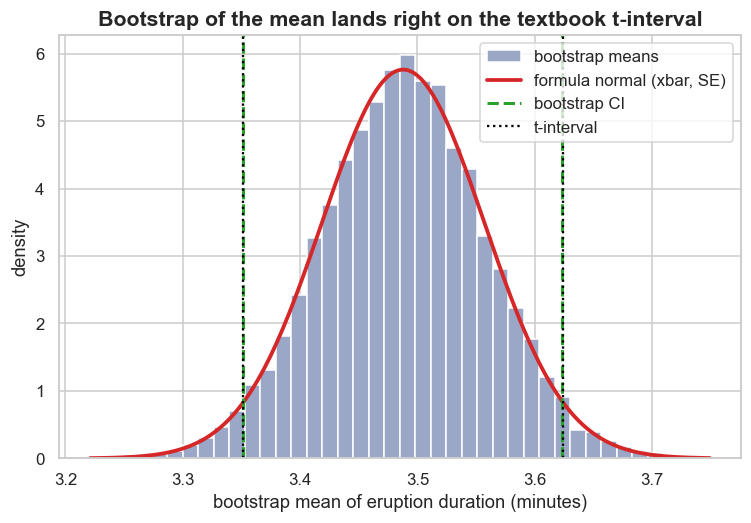

In [7]:
fig, ax = plt.subplots()
ax.hist(boot_means, bins=40, density=True, color='#9aa7c7', edgecolor='white', label='bootstrap means')
# Overlay the normal curve the formula assumes (centered at xbar, spread = SE):
xs = np.linspace(boot_means.min(), boot_means.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, xbar, se), color='#d62728', lw=2.5, label='formula normal (xbar, SE)')
ax.axvline(b_lo, color='#2ca02c', lw=2, ls='--'); ax.axvline(b_hi, color='#2ca02c', lw=2, ls='--', label='bootstrap CI')
ax.axvline(t_lo, color='black', lw=1.5, ls=':'); ax.axvline(t_hi, color='black', lw=1.5, ls=':', label='t-interval')
ax.set_xlabel('bootstrap mean of eruption duration (minutes)'); ax.set_ylabel('density')
ax.set_title('Bootstrap of the mean lands right on the textbook t-interval')
ax.legend(); plt.show()

The two intervals are essentially identical, and the bootstrap histogram traces the same normal curve
the formula assumes. That is the validation we wanted: **the bootstrap agrees with the textbook where
the textbook applies, so we can trust it on the median where the textbook is silent.**

## 5) The second tool: a permutation test for two groups

Now a different question — not "what's a range for one statistic?" but **"is the difference between
two groups real, or just luck?"** We switch datasets to **ToothGrowth**: 60 guinea pigs each given
vitamin C, half via **orange juice (OJ)** and half via a **synthetic supplement (VC)**. Did the
delivery method change tooth growth?

OJ group: n = 30, mean tooth length = 20.663
VC group: n = 30, mean tooth length = 16.963
OBSERVED difference (OJ - VC) = 3.700


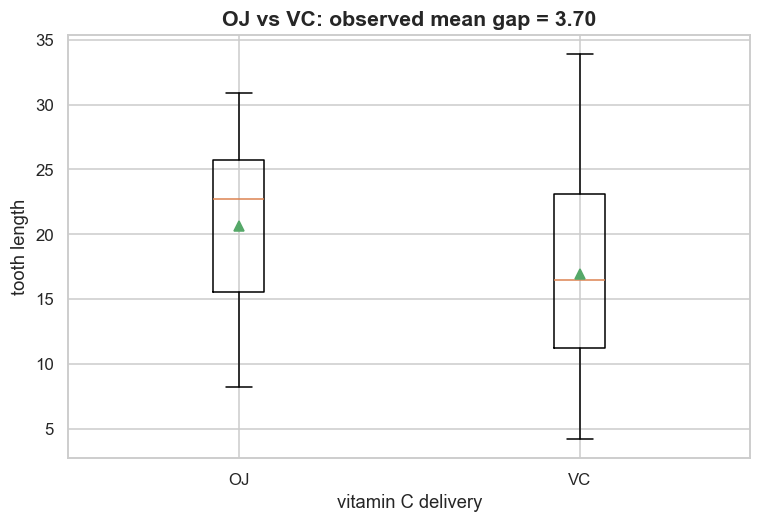

In [8]:
oj = tooth.loc[tooth['supp'] == 'OJ', 'len'].to_numpy()
vc = tooth.loc[tooth['supp'] == 'VC', 'len'].to_numpy()
observed_diff = oj.mean() - vc.mean()

print(f'OJ group: n = {len(oj)}, mean tooth length = {oj.mean():.3f}')
print(f'VC group: n = {len(vc)}, mean tooth length = {vc.mean():.3f}')
print(f'OBSERVED difference (OJ - VC) = {observed_diff:.3f}')

fig, ax = plt.subplots()
ax.boxplot([oj, vc], tick_labels=['OJ', 'VC'], showmeans=True)
ax.set_ylabel('tooth length'); ax.set_xlabel('vitamin C delivery')
ax.set_title(f'OJ vs VC: observed mean gap = {observed_diff:.2f}')
plt.show()

OJ looks higher by about **3.7** units. The question every test must answer: **could a gap that big
appear by pure chance even if the delivery method makes no difference at all?**

**The null hypothesis $H_0$:** the supplement label is irrelevant — OJ and VC are just two random
slices of one common pool of tooth lengths. If that were true, the "OJ" and "VC" tags would be
**interchangeable**. So we *simulate that null world directly*:

> **Pool all 60 lengths. Shuffle the 60 labels at random. Recompute (OJ mean − VC mean).** Repeat
> thousands of times. Because the labels are now random, this builds the distribution of the
> difference **when the null is true** — the "no real effect" world. Then we ask: how often does pure
> shuffling produce a gap as extreme as the **3.7** we actually saw? That fraction is the **p-value**.

No formula, no normality assumption — we **manufacture** the null distribution by shuffling.

In [9]:
def permutation_test(group_a, group_b, n_perm=20000, seed=0):
    '''Shuffle the group labels n_perm times; return (observed_diff, null_diffs).'''
    rng = np.random.default_rng(seed)
    pooled = np.concatenate([group_a, group_b])
    n_a = len(group_a)
    observed = group_a.mean() - group_b.mean()
    null = np.empty(n_perm)
    for i in range(n_perm):
        shuffled = rng.permutation(pooled)            # randomly reassign the labels
        null[i] = shuffled[:n_a].mean() - shuffled[n_a:].mean()
    return observed, null

observed_diff, null_diffs = permutation_test(oj, vc, n_perm=20000)

# Two-sided p-value: fraction of shuffles at least as extreme (in EITHER direction) as observed.
p_perm = np.mean(np.abs(null_diffs) >= np.abs(observed_diff))
print(f'Observed difference        = {observed_diff:.3f}')
print(f'Permutation (shuffle) p    = {p_perm:.4f}')
print(f'Std of the null shuffles   = {null_diffs.std():.3f}   (the "by-chance" wobble)')

Observed difference        = 3.700
Permutation (shuffle) p    = 0.0621
Std of the null shuffles   = 1.986   (the "by-chance" wobble)


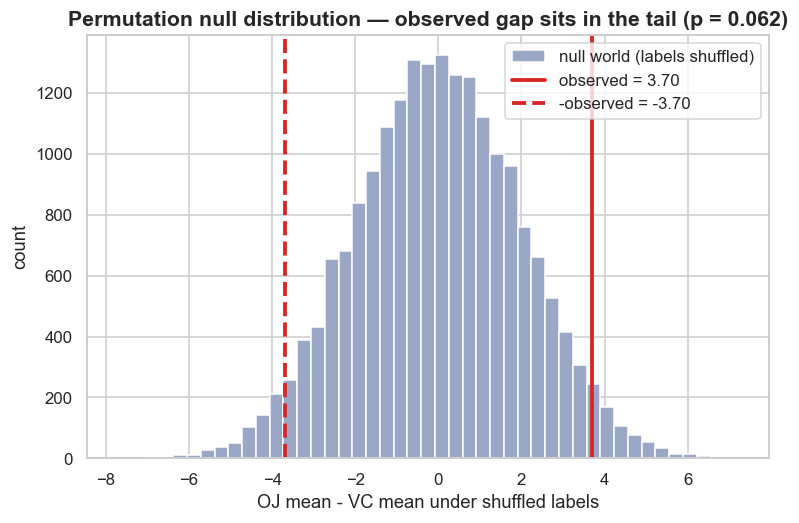

The red lines mark our observed gap and its mirror image. The p-value is the share of
the grey histogram out beyond them - the chance shuffling alone fakes a gap this big.


In [10]:
fig, ax = plt.subplots()
ax.hist(null_diffs, bins=45, color='#9aa7c7', edgecolor='white',
        label='null world (labels shuffled)')
ax.axvline(observed_diff, color='#d62728', lw=2.5, label=f'observed = {observed_diff:.2f}')
ax.axvline(-observed_diff, color='#d62728', lw=2.5, ls='--', label=f'-observed = {-observed_diff:.2f}')
ax.set_xlabel('OJ mean - VC mean under shuffled labels'); ax.set_ylabel('count')
ax.set_title(f'Permutation null distribution — observed gap sits in the tail (p = {p_perm:.3f})')
ax.legend(); plt.show()
print('The red lines mark our observed gap and its mirror image. The p-value is the share of')
print('the grey histogram out beyond them - the chance shuffling alone fakes a gap this big.')

## 6) Does it agree with the textbook t-test?

Same validation discipline as before: the classical tool here is the **two-sample t-test** (see the
t-tests lesson). If the permutation p-value matches `scipy`'s, we get the same scientific conclusion
with **fewer assumptions** (the permutation test never assumed the data was normal).

In [11]:
t_result = stats.ttest_ind(oj, vc, equal_var=True)   # classic two-sample (Student) t-test
print(f'Permutation test p-value = {p_perm:.4f}   (shuffling, no distribution assumed)')
print(f'scipy two-sample t-test  = {t_result.pvalue:.4f}   (assumes roughly normal data)')
print()
verdict = 'do NOT reject' if p_perm > 0.05 else 'reject'
print(f'Both p-values sit just ABOVE 0.05, so at the conventional 5% threshold we {verdict} H0:')
print('the OJ-vs-VC gap is suggestive but not quite "statistically significant" here.')
print('The two methods AGREE - and the permutation test earned that answer without assuming normality.')

Permutation test p-value = 0.0621   (shuffling, no distribution assumed)
scipy two-sample t-test  = 0.0604   (assumes roughly normal data)

Both p-values sit just ABOVE 0.05, so at the conventional 5% threshold we do NOT reject H0:
the OJ-vs-VC gap is suggestive but not quite "statistically significant" here.
The two methods AGREE - and the permutation test earned that answer without assuming normality.


Both methods land at about **p = 0.06** — a borderline result, just above the conventional 0.05 line.
That agreement is the reassuring part: when the textbook's assumptions roughly hold, the permutation
test reproduces its answer; when they *don't* hold (tiny, skewed, or weird-statistic data), the
permutation test keeps working while the formula quietly breaks.

> **Bootstrap vs. permutation — when to reach for which:**
>
> | | **Bootstrap** | **Permutation test** |
> |---|---|---|
> | **Answers** | "what's a confidence interval / SE for *this* statistic?" | "is the difference between groups real?" (a p-value) |
> | **The move** | resample **one** sample *with* replacement | pool and **shuffle labels** between groups |
> | **Built on** | your sample mimics the population | $H_0$: the labels are interchangeable |
> | **Shines when** | the statistic has no SE formula (median, ratio, correlation, ...) | comparing groups with no clean test or shaky assumptions |
> | **Limit** | only as good as the sample; rough for tiny $n$ | tests a *sharp* null ("no difference at all") |

## 7) The big idea — simulation is the throughline of the whole course

Step back and notice what just happened twice. We didn't memorize a new distribution table. We
**asked the computer to act out the situation thousands of times** and **read the answer off the
result.** That is the single thread running through this entire course:

- The Central Limit Theorem lesson: draw many samples, *watch* the means go normal.
- The confidence-interval flagship: build 100 intervals, *count* how many cover the truth.
- The hypothesis-testing lesson: simulate the null world, *see* where the data falls.
- And now the bootstrap and permutation test: resample and reshuffle to get inference for
  **any** statistic, with **minimal** assumptions.

Formulas are wonderful shortcuts for the cases they were derived for. **Resampling is the universal
fallback** for everything else — and, just as importantly, it makes the abstract idea of a "sampling
distribution under the null" something you can literally *see happen* on screen.

## Now you try

Predict first, then change a number and re-run:

1. **A different statistic, same machine.** In section 3, the `bootstrap_statistic` helper takes
   *any* function. In a new cell, bootstrap the **standard deviation** of eruptions:

       boot_sd = bootstrap_statistic(eruptions, lambda x: x.std(ddof=1), n_boot=10000)
       print(np.percentile(boot_sd, [2.5, 97.5]))

   You just got a CI for a quantity most textbooks never give you a formula for.

2. **How many resamples is enough?** Re-run the median bootstrap with `n_boot=200`, then `2000`, then
   `50000`. Watch the CI endpoints settle down. Why does more resampling help, and where does the
   benefit stop mattering? (Hint: resampling reduces *Monte-Carlo* noise, not the limits of your
   original sample.)

3. **Change the seed.** Both `bootstrap_statistic` and `permutation_test` take a `seed`. Try a few
   different seeds. The exact p-value and CI wiggle a little each time — by how much? That wiggle is
   the price of using simulation instead of an exact formula; bigger `n_boot` / `n_perm` shrinks it.

4. **Make the effect bigger.** The OJ-vs-VC gap was borderline (p ≈ 0.06). In a new cell, compare a
   pairing that should differ a lot — high-dose vs low-dose tooth length:

       hi = tooth.loc[tooth['dose'] == 2.0, 'len'].to_numpy()
       lo = tooth.loc[tooth['dose'] == 0.5, 'len'].to_numpy()
       obs, null = permutation_test(hi, lo, n_perm=20000)
       print(obs, np.mean(np.abs(null) >= abs(obs)))

   Does the observed gap now sit far out in the tail of the null? What does that p-value say?

## What you learned

- **Resampling replaces formulas:** when the math is hard or the assumptions fail, let the computer
  redo the experiment thousands of times and read the answer off the result.
- **The bootstrap** resamples your one sample *with replacement* to imitate the sampling distribution
  of **any** statistic; the **percentile method** (2.5th–97.5th percentiles) turns that into a 95%
  confidence interval — even for a **median**, which has no clean SE formula.
- **A method earns trust by agreeing with the old one:** the bootstrap CI for the *mean* lands right
  on the textbook t-interval, so we believe it on the median.
- **The permutation test** answers "is the group difference real?" by **pooling and shuffling the
  labels** to build the null distribution by hand; the **p-value** is the fraction of shuffles at
  least as extreme as what we observed.
- It **agreed with the two-sample t-test** (both p ≈ 0.06, a borderline OJ-vs-VC result) while
  assuming **less** — no normality required.
- **Bootstrap is for confidence intervals; permutation is for two-group p-values** — and each is only
  as good as the sample it starts from.
- **Simulation is the throughline of the course:** the CLT, the CI flagship, hypothesis testing, and
  now resampling all *show* you the sampling distribution instead of asking you to trust a formula.

---

**← Previous:** [Lesson 19: Multiple regression (intro)](19-multiple-regression.ipynb)  ·  [↑ Course map](../rendered/index.html)

**Same idea, another way:**  [Another dataset →](20-bootstrap-permutation~another-dataset.ipynb)  ·  [The code behind it →](20-bootstrap-permutation~the-code.ipynb)